# D2-03 Introduction to `edges` workflow and API

This notebook introduces the basic `edges` workflow through two small JSON methods: one with direct matching only, and one with location-specific characterization factors.


## Learning goals

After this notebook, you should be able to:

- inspect bundled `edges` JSON method files
- run a simple `EdgeLCIA` workflow with direct exchange matching
- understand how location constraints change the mapping process
- use the main helper functions for aggregate, dynamic, contained, and global fallback mappings
- inspect the exchange-level CFs actually applied in a calculation


## Background references

- Sacchi, R., Menacho, A. H., Seitfudem, G., Agez, M., Schlesinger-Martinat, J., Koyamparambath, A., Saldivar, J. S., Loubet, P., & Bauer, C. (2025). Contextual LCIA without the overhead: an exchange-based framework for flexible impact assessment. *The International Journal of Life Cycle Assessment, 30*(12), 3087-3101. https://doi.org/10.1007/s11367-025-02551-7
- Brightway documentation: https://docs.brightway.dev/
- Bundled `edges` JSON examples in `tutorials/DAY 2/assets/edges_examples/`


## 1) Locate the JSON examples used in this notebook

These two files are bundled with the course repository and are used directly below:

- `lcia_example_1.json`: direct exchange matching
- `lcia_example_2.json`: location-specific characterization with spatial helper mappings

The workflow cells below assume a Brightway project named `ecoinvent-3.10.1-cutoff`.


In [2]:
import json
from pathlib import Path

import bw2data as bd
import pandas as pd
from IPython.display import display
from edges import EdgeLCIA, get_available_methods

example_1_path = Path('assets/edges_examples/lcia_example_1.json')
example_2_path = Path('assets/edges_examples/lcia_example_2.json')

## 2) Example 1: a simple exchange-specific method

This first JSON method has only three rules:

- `Carbon dioxide` gets a CF of `1.0`
- `Methane, fossil` gets a CF of `28.0`
- `Dinitrogen monoxide` gets a CF of `265.0`

No location condition is used yet. The main lesson is the minimal `EdgeLCIA` workflow.


In [3]:
example_1_data = json.loads(example_1_path.read_text())
print(json.dumps(example_1_data, indent=2))

{
  "name": "Example LCIA Method",
  "version": "1.0",
  "description": "Example LCIA method for greenhouse gas emissions",
  "unit": "kg CO2e",
  "exchanges": [
    {
      "supplier": {
        "name": "Carbon dioxide",
        "operator": "startswith",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere"
      },
      "value": 1.0
    },
    {
      "supplier": {
        "name": "Methane, fossil",
        "operator": "contains",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere"
      },
      "value": 28.0
    },
    {
      "supplier": {
        "name": "Dinitrogen monoxide",
        "operator": "equals",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere"
      },
      "value": 265.0
    }
  ]
}


The next cell selects one activity from the `bafu` database.

In [4]:
bd.projects.set_current("aalborg-rlcia-2026")
db = bd.Database("bafu")
activity = db.random()
activity

'Heat, at system cogen 160kWe Jakobsberg, allocation energy' (megajoule, CH, None)

We now initiate the `EdgeLCIA` class like so:

In [5]:
lca_1 = EdgeLCIA(
    demand={activity: 1},
    filepath=str(example_1_path), # we point here to the JSON file
)

In [6]:
lca_1.lci() # we solve the system, as `bw2calc` usually does
lca_1.map_exchanges() # we map characterization factors with eligible edges
lca_1.evaluate_cfs() # we evlalute the factors
lca_1.lcia() # we compute H
print('Example 1 score:', lca_1.score)


Example 1 score: 0.09144463531693162


We can print some statistics about the mapping of exchanges

In [7]:
lca_1.statistics()

+----------------------+------------------------------------------+
|       Activity       | Heat, at system cogen 160kWe Jakobsberg, |
|                      |            allocation energy             |
|     Method name      |           Example LCIA Method            |
|         Unit         |                 kg CO2e                  |
|      Data file       |              lcia_example_1              |
|    CFs in method     |                    3                     |
|       CFs used       |                   4765                   |
|   Unique CFs used    |                    3                     |
|  Exc. characterized  |                   4765                   |
| Exc. uncharacterized |                  78179                   |
+----------------------+------------------------------------------+


And we can print a nice dataframe listing characterized (and uncharacterized) exchanges.

In [8]:
cf_table_1 = lca_1.generate_cf_table()
print(len(cf_table_1))
cf_table_1.head()

4765


,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,amount,CF,impact
0,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","xxx Electricity, high voltage, production ENTS...","xxx Electricity, high voltage, production ENTS...",ENTSO-E,9.857342e-13,265.0,2.612196e-10
1,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","xxx Electricity, high voltage, at grid","xxx Electricity, high voltage, at grid",CS,1.898483e-16,265.0,5.030980e-14
2,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Zeolite, slurry, 50% in H2O, at plant","Zeolite, slurry, 50% in H2O, at plant",RER,5.190589e-15,265.0,1.375506e-12
3,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Zeolite, powder, at plant","Zeolite, powder, at plant",RER,3.148659e-12,265.0,8.343946e-10
4,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Xylene, at plant","Xylene, at plant",RER,1.808702e-11,265.0,4.793061e-09


In [9]:
# we can also print all of the exchange, including those that did not get a CF
# just to check things
cf_table_1 = lca_1.generate_cf_table(
    # include_unmatched=True # if True, inclues ALL exchanges, even those without a CF -- can be a bit long.
)
print(len(cf_table_1))
cf_table_1.head()

4765


,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,amount,CF,impact
0,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","xxx Electricity, high voltage, production ENTS...","xxx Electricity, high voltage, production ENTS...",ENTSO-E,9.857342e-13,265.0,2.612196e-10
1,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","xxx Electricity, high voltage, at grid","xxx Electricity, high voltage, at grid",CS,1.898483e-16,265.0,5.030980e-14
2,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Zeolite, slurry, 50% in H2O, at plant","Zeolite, slurry, 50% in H2O, at plant",RER,5.190589e-15,265.0,1.375506e-12
3,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Zeolite, powder, at plant","Zeolite, powder, at plant",RER,3.148659e-12,265.0,8.343946e-10
4,biosphere,biosphere-technosphere,Dinitrogen monoxide,"(air,)","Xylene, at plant","Xylene, at plant",RER,1.808702e-11,265.0,4.793061e-09


In [10]:
(
    cf_table_1.groupby('supplier name')['CF']
    .mean()
    .sort_values(ascending=False)
    .to_frame('Mean CF')
)

,Mean CF
supplier name,
Dinitrogen monoxide,265.0
"Methane, fossil",28.0
"Carbon dioxide, fossil",1.0
"Carbon dioxide, from soil or biomass stock",1.0
"Carbon dioxide, in air",1.0
"Carbon dioxide, non-fossil",1.0


Wait, there's an issue here: isn't `Carbon dioxide, in air` supposed to represent CO2 uptake? How do we fix this?

## 3) Example 2: add consumer locations

This second JSON method still targets `Carbon dioxide`, but now the applied CF depends on the consumer location:

- `CH` gets `1.0`
- `FR` gets `2.0`
- `RER` gets `3.0`

So the workflow starts the same way, but direct matching alone will only cover the exchanges whose locations already match those rules.


In [11]:
example_2_data = json.loads(example_2_path.read_text())
print(json.dumps(example_2_data, indent=2))

{
  "name": "Example LCIA Method",
  "version": "1.0",
  "description": "Example LCIA method for greenhouse gas emissions",
  "unit": "kg CO2e",
  "exchanges": [
    {
      "supplier": {
        "name": "Carbon dioxide",
        "operator": "startswith",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere",
        "location": "CH"
      },
      "value": 1.0
    },
    {
      "supplier": {
        "name": "Carbon dioxide",
        "operator": "startswith",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere",
        "location": "FR"
      },
      "value": 2.0
    },
    {
      "supplier": {
        "name": "Carbon dioxide",
        "operator": "startswith",
        "matrix": "biosphere"
      },
      "consumer": {
        "matrix": "technosphere",
        "location": "RER"
      },
      "value": 3.0
    }
  ]
}


In [12]:
lca_2_direct = EdgeLCIA(
    demand={activity: 1},
    filepath=str(example_2_path),
)

In [13]:
lca_2_direct.lci()
lca_2_direct.map_exchanges()
lca_2_direct.evaluate_cfs()
lca_2_direct.lcia()
print('Example 2 score:', lca_2_direct.score)

Example 2 score: 0.07750651181687292


In [14]:
cf_table_2_direct = lca_2_direct.generate_cf_table()
cf_table_2_direct.head()

,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,amount,CF,impact
0,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Zeolite, slurry, 50% in H2O, at plant","Zeolite, slurry, 50% in H2O, at plant",RER,2.708470e-14,3.0,8.125409e-14
1,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Zeolite, powder, at plant","Zeolite, powder, at plant",RER,1.662726e-11,3.0,4.988178e-11
2,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Wood preservative, inorganic salt, containing ...","Wood preservative, inorganic salt, containing ...",RER,2.645440e-13,3.0,7.936321e-13
3,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Titanium dioxide, chloride process, at plant","Titanium dioxide, chloride process, at plant",RER,1.818243e-10,3.0,5.454730e-10
4,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Titanium dioxide at plant, sulphate process, a...","Titanium dioxide at plant, sulphate process, a...",RER,8.310793e-11,3.0,2.493238e-10


In [15]:
(
    cf_table_2_direct.groupby('consumer location')['CF']
    .mean()
    .sort_values(ascending=False)
    .to_frame('Mean CF')
)

,Mean CF
consumer location,
RER,3.0
FR,2.0
CH,1.0


## 4) Extend Example 2 with the spatial helper functions

We now add the helper functions that expand the geographic coverage:

- `map_aggregate_locations()` for aggregate regions such as `RER`
- `map_dynamic_locations()` for dynamic regions such as `RoW`
- `map_contained_locations()` for subregions contained in larger regions
- `map_remaining_locations_to_global()` for the final global fallback

This is the first full `edges` workflow that we will reuse later in Day 2.


In [16]:
lca_3 = EdgeLCIA(
    demand={activity: 1},
    filepath=str(example_2_path),
)

In [17]:
lca_3.lci()
lca_3.map_exchanges() # direct matches
lca_3.map_aggregate_locations() # handles aggregate locations
lca_3.map_dynamic_locations() # handles dynamic locations
lca_3.map_contained_locations() # handles contained locations
lca_3.map_remaining_locations_to_global() # handles the rest
lca_3.evaluate_cfs()
lca_3.lcia()
print('Example 2 score after helper mappings:', lca_3.score)

Example 2 score after helper mappings: 0.09740264891565939


In [18]:
lca_3.statistics()

+----------------------+------------------------------------------+
|       Activity       | Heat, at system cogen 160kWe Jakobsberg, |
|                      |            allocation energy             |
|     Method name      |           Example LCIA Method            |
|         Unit         |                 kg CO2e                  |
|      Data file       |              lcia_example_2              |
|    CFs in method     |                    3                     |
|       CFs used       |                   2094                   |
|   Unique CFs used    |                    6                     |
|  Exc. characterized  |                   2094                   |
| Exc. uncharacterized |                  80850                   |
+----------------------+------------------------------------------+


In [19]:
cf_table_3 = lca_3.generate_cf_table()
cf_table_3.head()

,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,amount,CF,impact
0,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Zeolite, slurry, 50% in H2O, at plant","Zeolite, slurry, 50% in H2O, at plant",RER,2.708470e-14,3.0,8.125409e-14
1,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Zeolite, powder, at plant","Zeolite, powder, at plant",RER,1.662726e-11,3.0,4.988178e-11
2,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Wood preservative, inorganic salt, containing ...","Wood preservative, inorganic salt, containing ...",RER,2.645440e-13,3.0,7.936321e-13
3,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Titanium dioxide, chloride process, at plant","Titanium dioxide, chloride process, at plant",RER,1.818243e-10,3.0,5.454730e-10
4,biosphere,biosphere-technosphere,"Carbon dioxide, from soil or biomass stock","(air, non-urban air or from high stacks)","Titanium dioxide at plant, sulphate process, a...","Titanium dioxide at plant, sulphate process, a...",RER,8.310793e-11,3.0,2.493238e-10


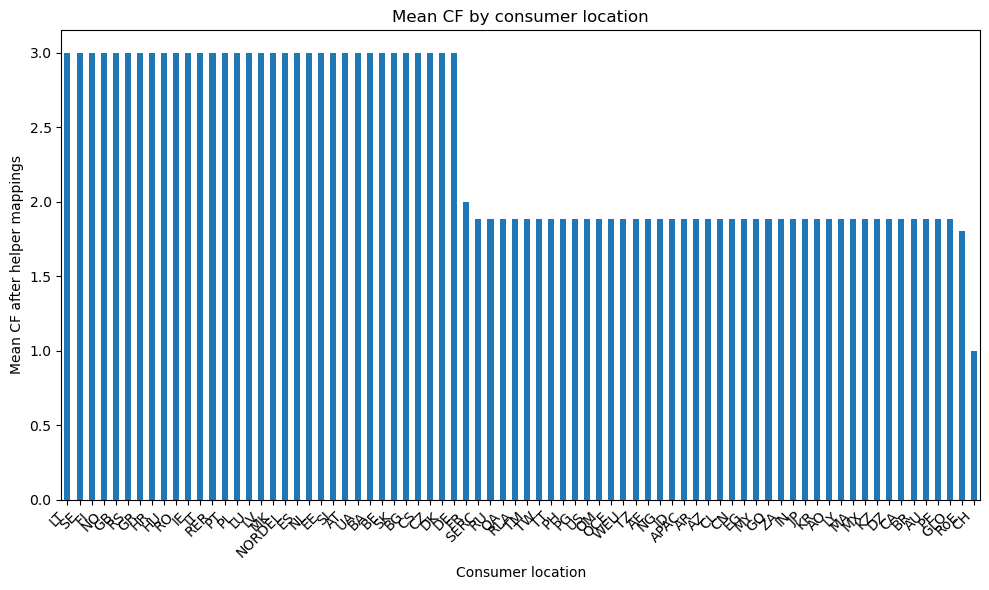

In [20]:
import matplotlib.pyplot as plt

(
    cf_table_3.groupby("consumer location")["CF"]
    .mean()
    .sort_values(ascending=False)
    .plot.bar(figsize=(10, 6))
)

plt.ylabel("Mean CF after helper mappings")
plt.xlabel("Consumer location")
plt.title("Mean CF by consumer location")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 5) Preview the built-in method library

Besides ad hoc JSON files, `edges` also ships pre-generated method definitions.


In [21]:
available_methods = get_available_methods()
print('Number of available methods:', len(available_methods))

for method in available_methods:
    print(method)


Number of available methods: 91
('AWARE 2.0', 'Country', 'all', 'yearly')
('AWARE 2.0', 'Country', 'irri', 'yearly')
('AWARE 2.0', 'Country', 'non', 'irri', 'yearly')
('AWARE 2.0', 'Country', 'unspecified', 'yearly')
('GLAM3', 'biodiversity', 'occupation', 'average', 'amphibians')
('GLAM3', 'biodiversity', 'occupation', 'average', 'birds')
('GLAM3', 'biodiversity', 'occupation', 'average', 'eukaryota')
('GLAM3', 'biodiversity', 'occupation', 'average', 'mammals')
('GLAM3', 'biodiversity', 'occupation', 'average', 'plants')
('GLAM3', 'biodiversity', 'occupation', 'average', 'reptiles')
('GLAM3', 'biodiversity', 'transformation', 'average', 'amphibians')
('GLAM3', 'biodiversity', 'transformation', 'average', 'birds')
('GLAM3', 'biodiversity', 'transformation', 'average', 'eukaryota')
('GLAM3', 'biodiversity', 'transformation', 'average', 'mammals')
('GLAM3', 'biodiversity', 'transformation', 'average', 'plants')
('GLAM3', 'biodiversity', 'transformation', 'average', 'reptiles')
('GeoPolR

## Recap

After this notebook, you should now be able to:

- connect the local `edges` example notebooks to their JSON method files
- run the minimal `EdgeLCIA` workflow from `lci()` to `lcia()`
- explain why regionalized methods need more than direct exchange matching
- identify the main helper functions used to broaden spatial coverage
- inspect the exchange-level CFs and weights used by `edges`
